# comparing UMAPs pre and post resolvi to show decrease in transcript diffusion etc

In [1]:
import scanpy as sc 

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 193025 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    var: 'gene_ids', 'feature_types', 'genom

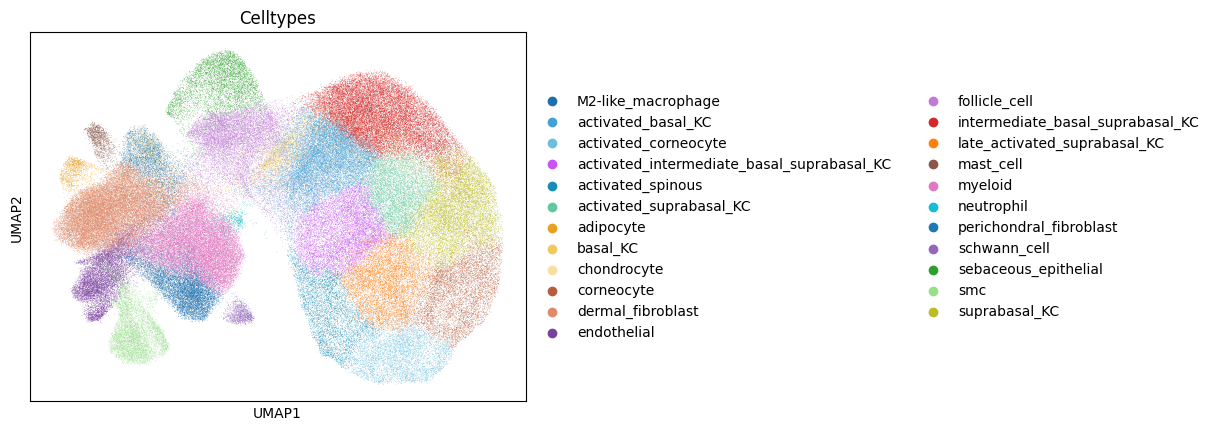

In [2]:
sc.pl.umap(adata, color = ['celltype_assignments'], title = 'Celltypes')

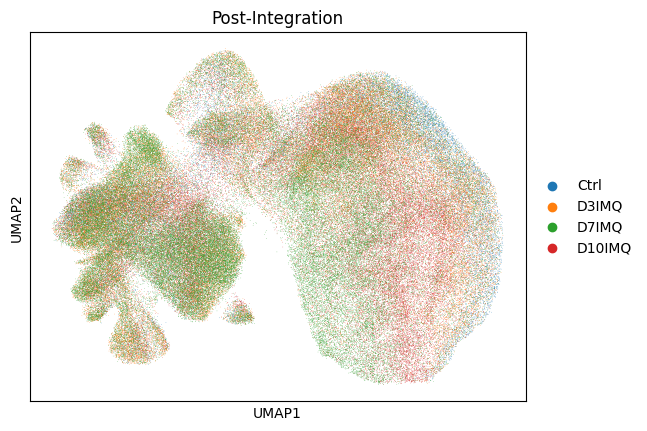

In [4]:
sc.pl.umap(adata, color = ['condition'], title = 'Post-Integration')

In [23]:
adata.uns['celltype_assignments_colors'] = ['#1a6faf', 
                                            '#45a0d6', 
                                            "#69bfde", 
                                            "#c954f4", 
                                            "#178db4",
                                              '#60c89d',
                                                '#e8a020',
                                                  '#f5c85a',
                                                    '#f7dfa0',
                                                      '#b85c3a', 
                                                      '#e08a6a', 
                                                      '#7b3fa0', 
                                                      '#c07bd6', 
                                                      '#d62728', 
                                                      '#ff7f0e', 
                                                      '#8c564b', 
                                                      '#e377c2', 
                                                      '#17becf', 
                                                      '#1f77b4', 
                                                      '#9467bd', 
                                                      '#2ca02c', 
                                                      '#98df8a', 
                                                      '#bcbd22', 
                                                      '#ff9896']

In [5]:
#doing a UMAP for everything pre-resolVI

scales_counts = sc.pp.normalize_total(adata, target_sum = None, inplace = False)
#log1p transform
adata.layers['log1p_norm'] = sc.pp.log1p(scales_counts["X"], copy = True)

In [6]:
sc.tl.pca(adata, n_comps = 15)

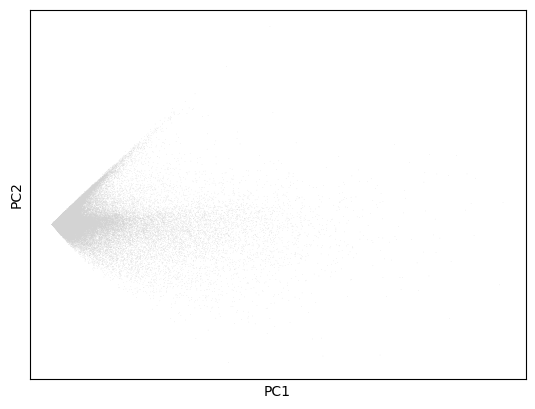

In [31]:
sc.pl.pca(adata)

In [7]:
sc.pp.neighbors(adata, use_rep = 'X_pca', key_added='raw_neighbours')

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
sc.tl.umap(adata, neighbors_key='raw_neighbours')

In [9]:
sc.tl.leiden(adata, resolution = 0.75, flavor = 'igraph',neighbors_key='raw_neighbours', key_added = 'raw_leiden_0.75') 

In [45]:
adata

AnnData object with n_obs × n_vars = 193025 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex', 'raw_leiden_0.5'
    var: 'gene_ids', 'feat

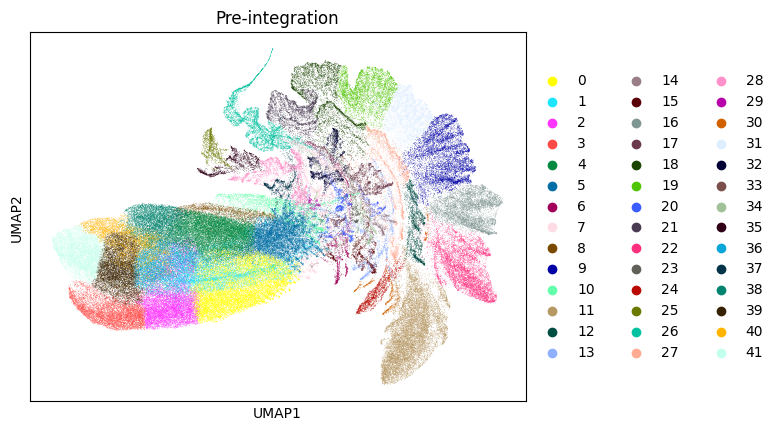

In [12]:
sc.pl.umap(adata, color = 'raw_leiden_0.75', title = 'Pre-integration')

In [17]:
import numpy as np

for cluster in sorted(adata.obs['raw_leiden_0.75'].unique()):
    df = adata.obs[adata.obs['raw_leiden_0.75'] == cluster]
    print(f'{cluster}: {np.mean(df['transcript_counts'])}')

0: 81.50457396759018
1: 71.89373904731559
10: 110.6820883949341
11: 20.824792654028435
12: 26.942932396839332
13: 32.89155370177268
14: 32.90437361008154
15: 29.62607626076261
16: 21.63304647160069
17: 30.234756097560975
18: 45.82840370286746
19: 31.329968595782862
2: 193.66684406599254
20: 31.212247016087183
21: 53.56064281382656
22: 21.510246469122126
23: 37.44709388971684
24: 21.00532859680284
25: 20.51493710691824
26: 103.11363636363636
27: 40.362803075103486
28: 40.377424023154845
29: 29.264900662251655
3: 432.45326378119273
30: 20.075514874141877
31: 27.40020366598778
32: 28.327152317880795
33: 33.940568475452196
34: 35.6867000556483
35: 25.09796437659033
36: 148.20040737806949
37: 39.659049360146255
38: 392.94007280873706
39: 360.31432954109675
4: 122.61410381978453
40: 563.7418790118654
41: 871.9145197065347
5: 44.3103909121283
6: 35.2544420753376
7: 40.54438257451687
8: 167.64319695528067
9: 26.04926931106472


M2-like_macrophage: 38.23376918703809


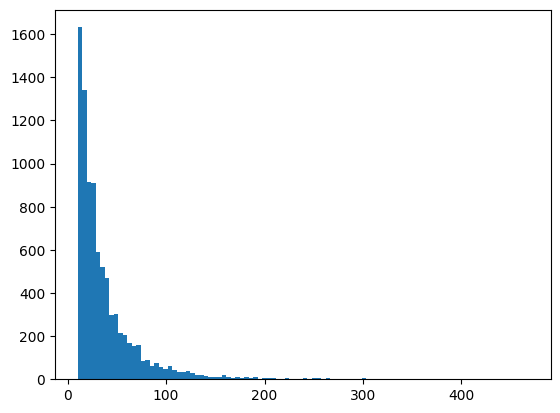

activated_basal_KC: 217.8855041333073


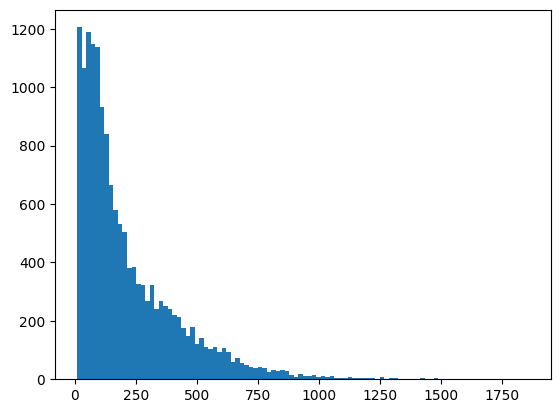

activated_corneocyte: 153.7057706909643


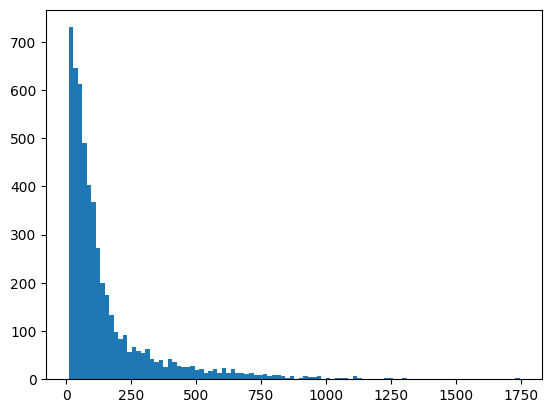

activated_intermediate_basal_suprabasal_KC: 474.6553852703278


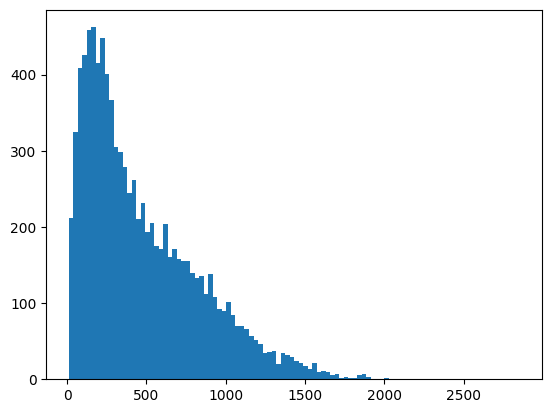

activated_spinous: 503.3997700268302


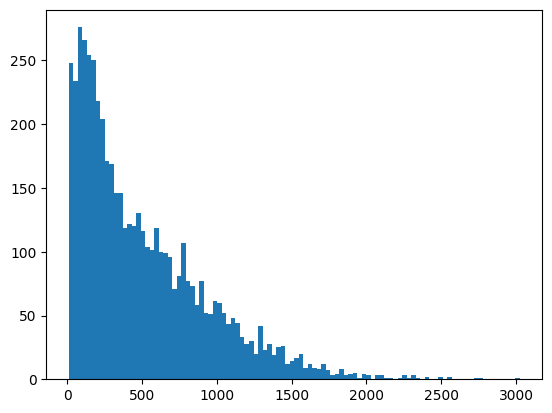

activated_suprabasal_KC: 262.6704266088214


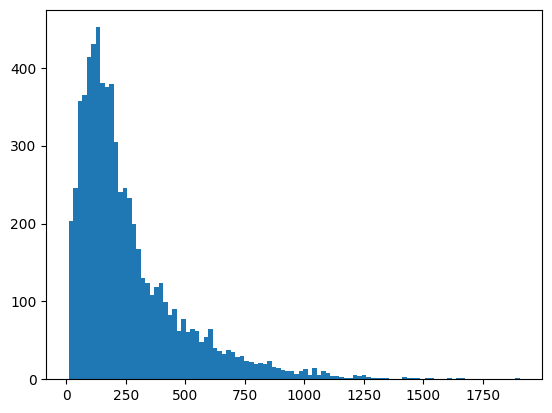

adipocyte: 40.78471248246844


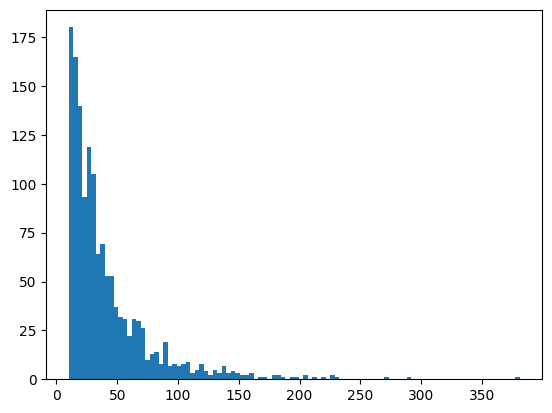

basal_KC: 93.06560975609756


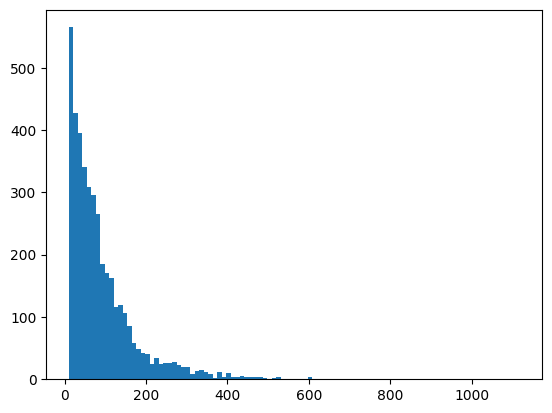

chondrocyte: 24.754055468341182


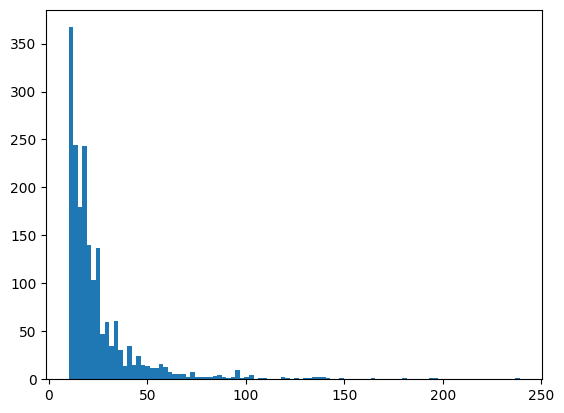

corneocyte: 211.09777082518576


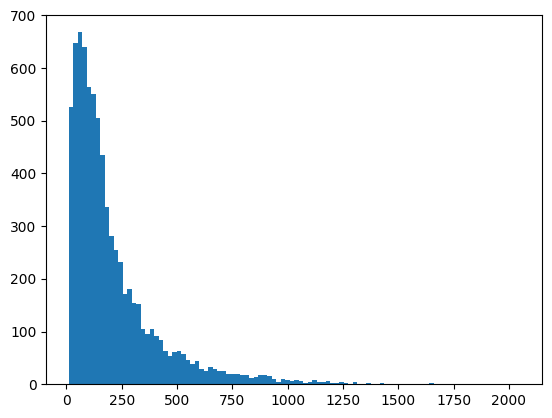

dermal_fibroblast: 33.96634071440116


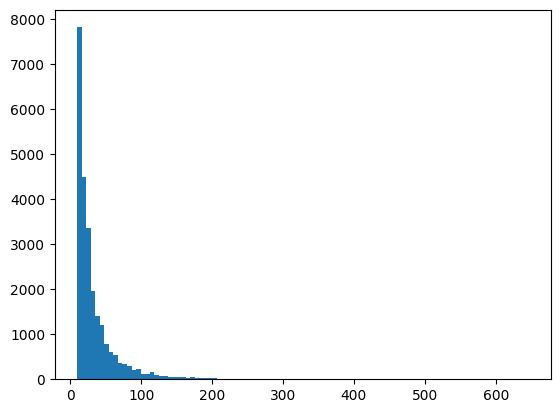

endothelial: 35.30377580489892


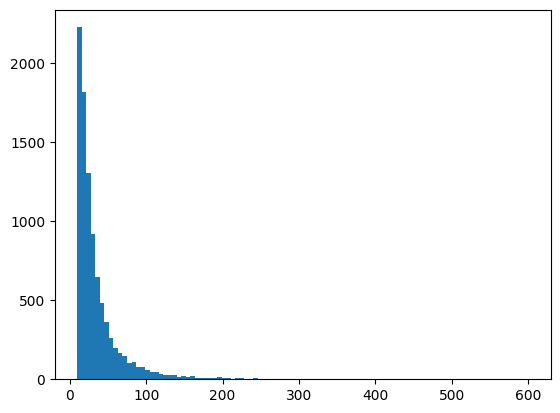

follicle_cell: 82.72641661300709


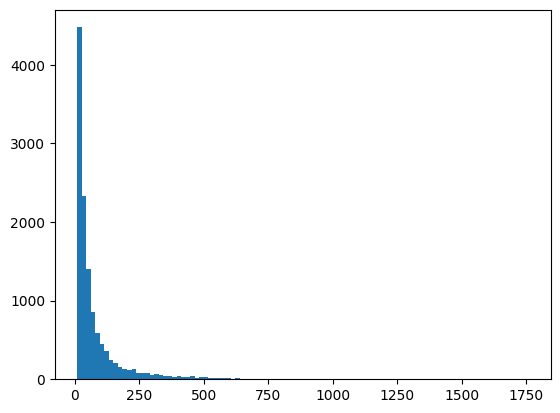

intermediate_basal_suprabasal_KC: 131.80992366412212


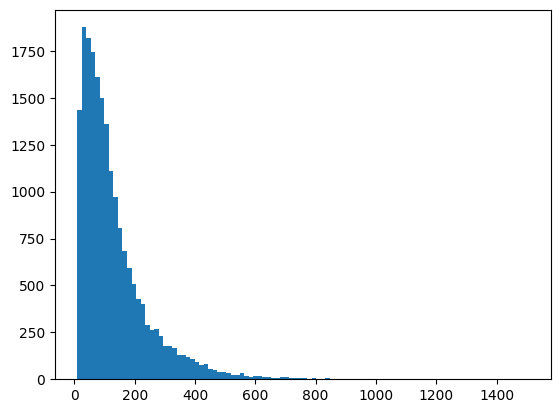

late_activated_suprabasal_KC: 358.3317610062893


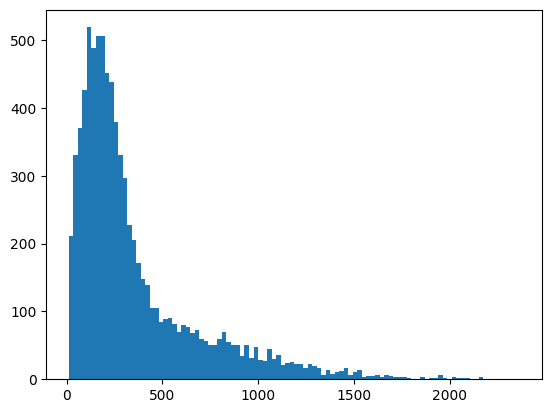

mast_cell: 36.24


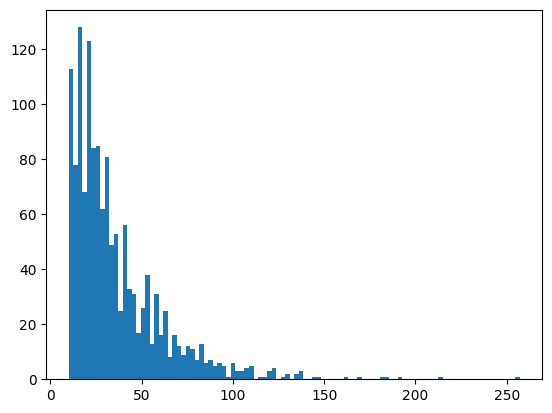

myeloid: 32.45573649490243


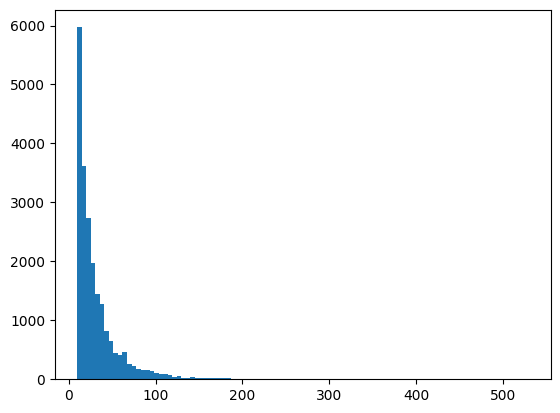

neutrophil: 26.106312292358805


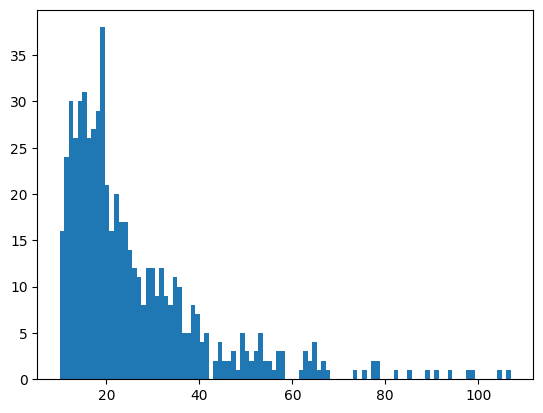

perichondral_fibroblast: 22.642113482561165


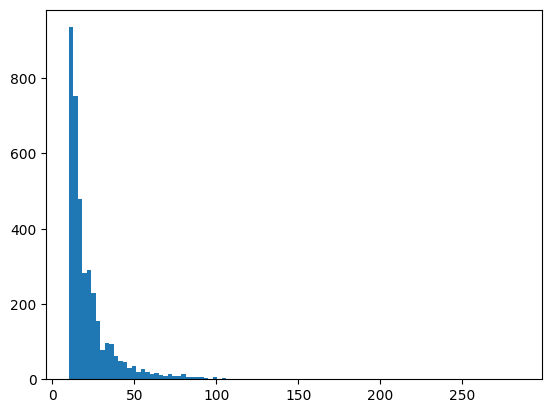

schwann_cell: 25.946718146718148


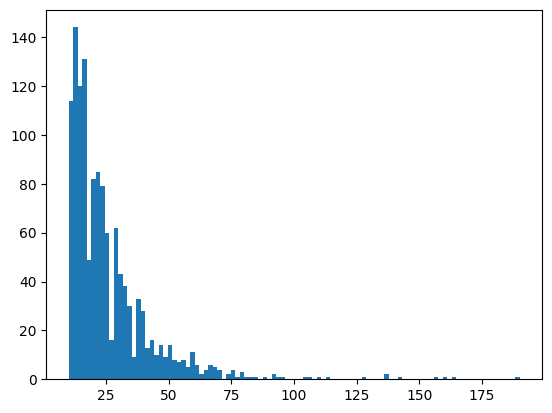

sebaceous_epithelial: 91.39108031272211


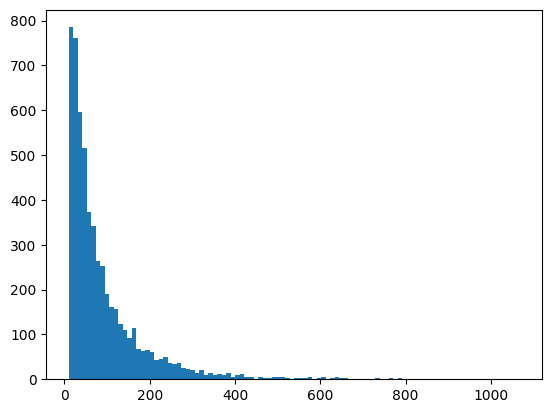

smc: 47.88180711895345


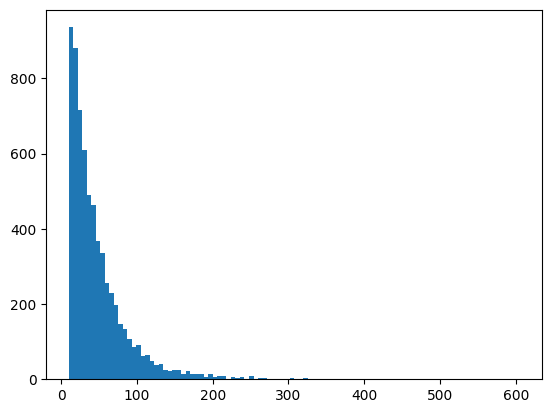

suprabasal_KC: 214.35506301607995


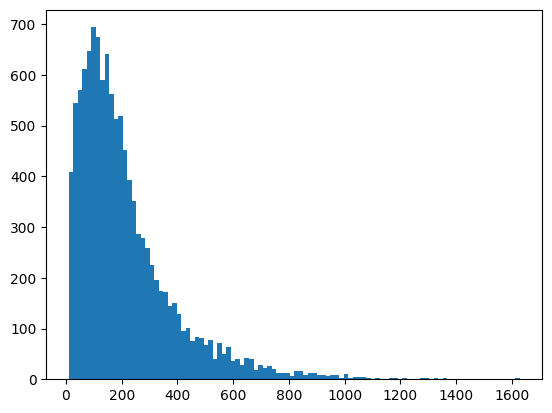

In [20]:
import numpy as np
import matplotlib.pyplot as plt

for cluster in sorted(adata.obs['celltype_assignments'].unique()):
    df = adata.obs[adata.obs['celltype_assignments'] == cluster]
    print(f'{cluster}: {np.mean(df['transcript_counts'])}')
    plt.hist(df['transcript_counts'], bins = 100)
    plt.show()